<a href="https://colab.research.google.com/github/karagoz-matias/Data-Science-WPO/blob/main/causal_inference_exercise_session_simple.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Causal Inference Lab: (Simple Code Version): `econml` S-Learner, T-Learner, Propensity Scores, and Matching

This is a guided, hands-on causal inference session.

You will learn four effect-estimation approaches on observational data:

1. S-learner (`econml`)
2. T-learner (`econml`)
3. Propensity score + inverse probability weighting (IPW)
4. Propensity score matching

You will also build intuition for why naive estimates are valid in randomized trials but biased in confounded observational settings.


## Lecture Connection Map

This notebook is designed to follow the lecture arc:

- **Lecture 1**: causal vs predictive thinking, potential outcomes, fundamental problem, ATE, RCT intuition.
- **Lecture 2**: identification assumptions in observational data (exchangeability, positivity/overlap, consistency, no interference).
- **Lecture 3**: DAG-based control selection, backdoor criterion, collider bias.
- **Lecture 4**: matching, propensity scores, IPW, and meta-learners (S/T) with model-choice benchmarking.


In [ ]:
# Notebook bootstrap: install required packages if missing.
import importlib.util as iu
import subprocess
import sys

required = {
    'econml': 'econml',
    'dowhy': 'dowhy',
    'sklearn': 'scikit-learn',
    'pandas': 'pandas',
    'scipy': 'scipy',
    'matplotlib': 'matplotlib',
    'numpy': 'numpy',
}
missing = [pkg for mod, pkg in required.items() if iu.find_spec(mod) is None]

if missing:
    print('Installing missing packages:', missing)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', *missing])
    print('Installation complete. Re-run the next import cell.')
else:
    print('All required packages already available.')




Installing missing packages: ['econml', 'dowhy']
Installation complete. Re-run the next import cell.


In [ ]:
import warnings
warnings.filterwarnings('ignore', message='.*force_all_finite.*')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import NearestNeighbors
from scipy.stats import ttest_rel

from econml.metalearners import SLearner, TLearner
from dowhy import CausalModel

plt.style.use('ggplot')
np.set_printoptions(precision=3, suppress=True)


## Step 0: RCT vs Non-RCT Intuition

Lecture connection: **Lecture 1** (correlation vs causation, RCT motivation) and **Lecture 2** (exchangeability).

We compare two worlds with the same potential outcomes:

- **Non-RCT**: treatment depends on covariates (`W <- f(X)`), so confounding exists.
- **RCT**: treatment is randomized (`W ~ Bernoulli(0.5)`), so groups are comparable in expectation.

The naive treated-control mean difference is unbiased in RCTs (up to sampling error), but biased in confounded observational data.


In [ ]:
# Generate observational (non-RCT) data
rng_obs = np.random.default_rng(123)
n_obs = 2200 #The larger the sample size, the more the sample mean will gravitate towards the true mean
x1 = rng_obs.normal(0.0, 1.0, n_obs)
x2 = rng_obs.normal(0.0, 1.0, n_obs)
x3 = rng_obs.binomial(1, 0.45, n_obs).astype(float)

X_obs = np.column_stack([x1, x2, x3]) # All the covariates are stacked in a single column
prop_obs = 1.0 / (1.0 + np.exp(-(-0.2 + 1.0 * x1 - 0.85 * x2 + 0.6 * x3))) # logistic regression -> sigmoid function squashes the original function between 0 and 1
#Exact convergence to the true ATE if we reduce bias by removing the effects of the features, you reduce the interference of the features
w_obs = rng_obs.binomial(1, prop_obs).astype(int) # treatment is dependent on pro_obs, the latter is dependent on covariates

tau_obs = 1.3 + 0.7 * x1
mu0_obs = 2.0 + 1.2 * x1 - 1.1 * x2 + 0.8 * x3 + 0.5 * x1 * x2
y_obs = mu0_obs + tau_obs * w_obs + rng_obs.normal(0.0, 1.0, n_obs)

#outcome is dependent on covariates via mu0_obs and on treatment w_obs (itself dependent on covariates)

obs = {
    'X': X_obs,
    'w': w_obs,
    'y': y_obs,
    'true_propensity': prop_obs,
    'true_tau': tau_obs,
    'true_ate': float(np.mean(tau_obs)),
}

# Generate RCT data on the same covariates/potential outcomes
rng_rct = np.random.default_rng(123)
w_rct = rng_rct.binomial(1, 0.5, n_obs).astype(int)
y_rct = mu0_obs + tau_obs * w_rct + rng_rct.normal(0.0, 1.0, n_obs)

rct = {
    'X': X_obs,
    'w': w_rct,
    'y': y_rct,
    'true_ate': float(np.mean(tau_obs)),
}

naive_obs = obs['y'][obs['w'] == 1].mean() - obs['y'][obs['w'] == 0].mean()
naive_rct = rct['y'][rct['w'] == 1].mean() - rct['y'][rct['w'] == 0].mean()

print(f"True ATE: {obs['true_ate']:.3f}")
print(f"Naive Non-RCT estimate: {naive_obs:.3f} (bias {naive_obs - obs['true_ate']:+.3f})")
print(f"Naive RCT estimate:     {naive_rct:.3f} (bias {naive_rct - rct['true_ate']:+.3f})")


True ATE: 1.311
Naive Non-RCT estimate: 3.421 (bias +2.110)
Naive RCT estimate:     1.065 (bias -0.246)


### SMD (Standardized Mean Difference): What It Means

The **Standardized Mean Difference (SMD)** compares a covariate between treated and control groups on a common scale.

For a covariate $X_j$:

$$
\text{SMD}(X_j) = \frac{\bar{X}_{j,\,T=1} - \bar{X}_{j,\,T=0}}{\sqrt{\frac{s^2_{j,\,T=1}+s^2_{j,\,T=0}}{2}}}
$$

What it measures:
- **Balance** between treated and control on each covariate
- Magnitude is unit-free (so different variables are comparable)
- Sign shows direction: positive means treated group has higher average

Common interpretation guidelines (using $|\text{SMD}|$):
- `< 0.10`: very good balance
- `0.10 - 0.20`: mild imbalance (often acceptable, context-dependent)
- `> 0.20`: notable imbalance, potential confounding risk

In this notebook, we use SMD before and after adjustment (e.g., weighting) to check whether groups become more comparable.


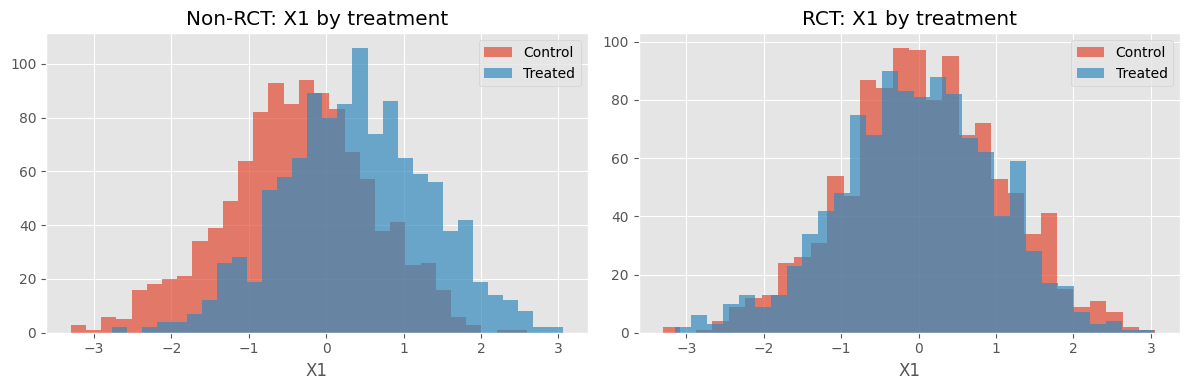


SMD by covariate (X1, X2, X3):
  Non-RCT: [0.79, -0.728, 0.227]
  RCT:     [-0.084, 0.078, -0.029]


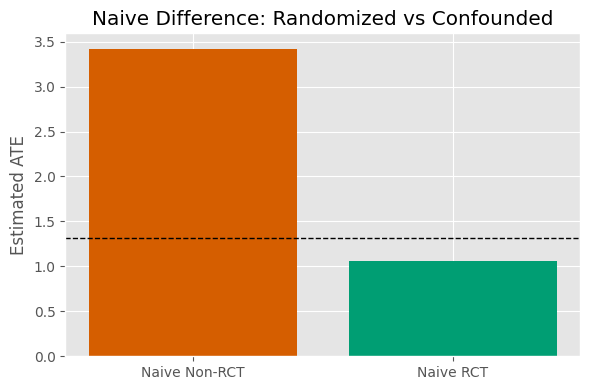

In [ ]:
# histogram computation
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

X_obs = obs['X']
X_rct = rct['X']

ax[0].hist(X_obs[obs['w'] == 0, 0], bins=30, alpha=0.7, label='Control') # Here we compute a histogram where the we use observational non treated data
ax[0].hist(X_obs[obs['w'] == 1, 0], bins=30, alpha=0.7, label='Treated') # Here we compute a histogram where the we use observational treated data
ax[0].set_title('Non-RCT: X1 by treatment')
ax[0].set_xlabel('X1')
ax[0].legend()

ax[1].hist(X_rct[rct['w'] == 0, 0], bins=30, alpha=0.7, label='Control') # Here we compute a histogram where the we use rct non treated data
ax[1].hist(X_rct[rct['w'] == 1, 0], bins=30, alpha=0.7, label='Treated') # Here we compute a histogram where the we use rct treated data
ax[1].set_title('RCT: X1 by treatment')
ax[1].set_xlabel('X1')
ax[1].legend()

plt.tight_layout()
plt.show()

# smd computation
smd_obs = []
smd_rct = []
for j in range(3): # this for loop runs over the 3 different covariates x1, x2, x3
    xj_obs = X_obs[:, j]
    mt_obs = xj_obs[obs['w'] == 1].mean() # Here we take the mean of the observational treatment group
    mc_obs = xj_obs[obs['w'] == 0].mean()
    vt_obs = xj_obs[obs['w'] == 1].var() # Here we take the variance of the observational treatment group
    vc_obs = xj_obs[obs['w'] == 0].var()
    smd_obs.append(float((mt_obs - mc_obs) / np.sqrt((vt_obs + vc_obs) / 2 + 1e-12)))

    xj_rct = X_rct[:, j]
    mt_rct = xj_rct[rct['w'] == 1].mean() # Here we take the mean of the rct treatment group
    mc_rct = xj_rct[rct['w'] == 0].mean()
    vt_rct = xj_rct[rct['w'] == 1].var() # Here we take the variance of the rct treatment group
    vc_rct = xj_rct[rct['w'] == 0].var()
    smd_rct.append(float((mt_rct - mc_rct) / np.sqrt((vt_rct + vc_rct) / 2 + 1e-12)))

print('\nSMD by covariate (X1, X2, X3):')
print('  Non-RCT:', [round(v, 3) for v in smd_obs])
print('  RCT:    ', [round(v, 3) for v in smd_rct])

# Visualisation of estimated ATE related to true ATE
plt.figure(figsize=(6, 4))
plt.bar(['Naive Non-RCT', 'Naive RCT'], [naive_obs, naive_rct], color=['#d55e00', '#009e73'])
plt.axhline(obs['true_ate'], color='black', linestyle='--', linewidth=1)
plt.ylabel('Estimated ATE')
plt.title('Naive Difference: Randomized vs Confounded')
plt.tight_layout()
plt.show()


### Exercise 0

1. Why is naive treated-vs-control difference causal in RCTs but biased in non-RCTs?
#Because of the confounding role of covariates on treatment.

2. Which plot features indicate confounding in the observational setting?
#We observe that there is no overlapping between control and treatment group, indicating that positivity is violated.

3. If an RCT has noncompliance, which estimand remains straightforward (and which does not)?
#Then we identify the effect of sending the treatment and not taking it


## Step 0.5: Potential Outcomes and the Fundamental Problem

Lecture connection: **Lecture 1** (`Potential outcomes`, `Fundamental problem of causal inference`).

Potential outcomes notation makes the causal target explicit:

- `Y(1)`: outcome if treated
- `Y(0)`: outcome if not treated
- individual effect: `tau_i = Y_i(1) - Y_i(0)`
- average treatment effect: `ATE = E[Y(1) - Y(0)]`

The **fundamental problem of causal inference**: for each unit, we only observe one potential outcome.


In [ ]:
rng_toy = np.random.default_rng(42)
n_toy = 8
x_toy = np.linspace(-1.6, 1.6, n_toy)

y0_toy = 2.0 + 0.7 * x_toy
tau_toy = 1.1 + 0.5 * x_toy
y1_toy = y0_toy + tau_toy

t_obs = rng_toy.binomial(1, 0.5, size=n_toy)
y_obs = np.where(t_obs == 1, y1_toy, y0_toy)
y_missing = np.where(t_obs == 1, y0_toy, y1_toy)

po_df = pd.DataFrame({
    'unit': np.arange(1, n_toy + 1),
    'X1': np.round(x_toy, 2),
    'T observed': t_obs,
    'Y(0)': np.round(y0_toy, 2),
    'Y(1)': np.round(y1_toy, 2),
    'Observed Y = Y(T)': np.round(y_obs, 2),
    'Missing counterfactual Y(1-T)': np.round(y_missing, 2),
})

print('Toy table showing observed and missing potential outcomes:')
print(po_df.to_string(index=False))
print(f"\nTrue individual effects in this toy data: {np.round(tau_toy, 2)}")
print(f"True ATE in this toy data: {np.mean(tau_toy):.3f}")





Toy table showing observed and missing potential outcomes:
 unit    X1  T observed  Y(0)  Y(1)  Observed Y = Y(T)  Missing counterfactual Y(1-T)
    1 -1.60           1  0.88  1.18               1.18                           0.88
    2 -1.14           0  1.20  1.73               1.20                           1.73
    3 -0.69           1  1.52  2.28               2.28                           1.52
    4 -0.23           1  1.84  2.83               2.83                           1.84
    5  0.23           0  2.16  3.37               2.16                           3.37
    6  0.69           1  2.48  3.92               3.92                           2.48
    7  1.14           1  2.80  4.47               4.47                           2.80
    8  1.60           1  3.12  5.02               5.02                           3.12

True individual effects in this toy data: [0.3  0.53 0.76 0.99 1.21 1.44 1.67 1.9 ]
True ATE in this toy data: 1.100


### Exercise 0.5

1. In real data, which potential-outcome column is always missing for each unit?
# The counterfactual, so the outcome of the non-observed treatment

2. Why does that make causal inference fundamentally harder than prediction?
# Because you have to predict a treatment effect with training data that is incomplete, in contrast with traditional ML where you have all the outcome data in your training data (training, validation and test set)

# Furthermore ther's confounding and unconfoundedness is an untestable assumption
3. What does randomization solve here, and what does it still not let us observe?
# It enables to rely on the ATE because it makes sure that there's no confounding.


## Step 1: Generate Confounded Observational Data

Lecture connection: **Lecture 2** (identification assumptions in observational data).

Now focus on the non-RCT setting where treatment assignment is confounded.

Assumption checkpoint (used throughout the rest of the notebook):

- **Conditional exchangeability / unconfoundedness**: after adjusting for observed confounders, treatment assignment is as-good-as random.
- **Positivity / overlap**: each covariate profile has a non-zero chance of both treatment and control.
- **Consistency + no interference**: observed outcome under received treatment matches the corresponding potential outcome, and one unit’s treatment does not affect another unit’s outcome.


In [ ]:
# Generate one confounded observational dataset for the rest of the notebook
rng = np.random.default_rng(11)
n = 5000

x1 = rng.normal(0.0, 1.0, n)
x2 = rng.normal(0.0, 1.0, n)
x3 = rng.binomial(1, 0.45, n).astype(float)
X = np.column_stack([x1, x2, x3])

true_propensity = 1.0 / (1.0 + np.exp(-(-0.2 + 1.0 * x1 - 0.85 * x2 + 0.6 * x3)))
w = rng.binomial(1, true_propensity).astype(int)

true_tau = 1.3 + 0.7 * x1
mu0 = 2.0 + 1.2 * x1 - 1.1 * x2 + 0.8 * x3 + 0.5 * x1 * x2
y = mu0 + true_tau * w + rng.normal(0.0, 1.0, n)

data = {
    'X': X,
    'w': w,
    'y': y,
    'true_propensity': true_propensity,
    'true_tau': true_tau,
    'true_ate': float(np.mean(true_tau)),
}

naive_diff = y[w == 1].mean() - y[w == 0].mean()

print(f"Samples: {len(y)}")
print(f"True ATE: {data['true_ate']:.3f}")
print(f"Treatment rate: {w.mean():.3f}")
print(f"Naive treated-control difference: {naive_diff:.3f}")
print(f"Naive bias: {naive_diff - data['true_ate']:+.3f}")


Samples: 5000
True ATE: 1.306
Treatment rate: 0.522
Naive treated-control difference: 3.185
Naive bias: +1.879


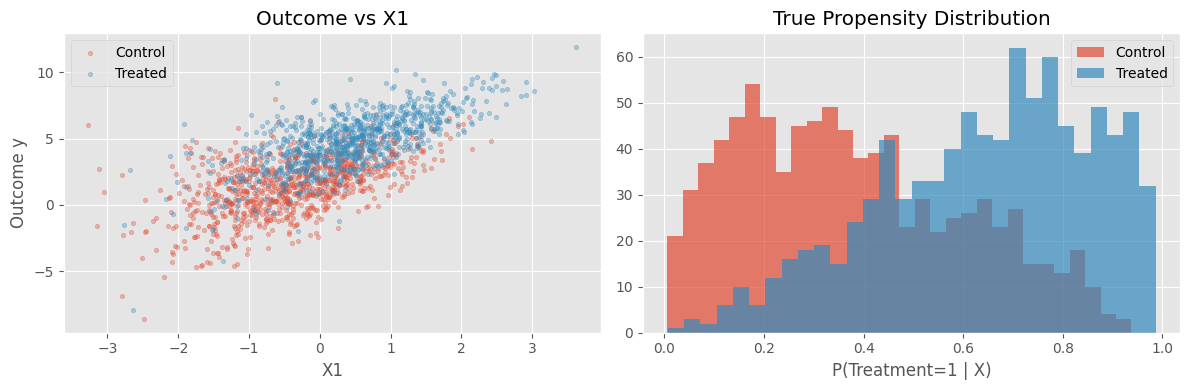

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].scatter(X[w == 0, 0], y[w == 0], s=10, alpha=0.35, label='Control')
ax[0].scatter(X[w == 1, 0], y[w == 1], s=10, alpha=0.35, label='Treated')
ax[0].set_title('Outcome vs X1')
ax[0].set_xlabel('X1')
ax[0].set_ylabel('Outcome y')
ax[0].legend()

ax[1].hist(data['true_propensity'][w == 0], bins=30, alpha=0.7, label='Control')
ax[1].hist(data['true_propensity'][w == 1], bins=30, alpha=0.7, label='Treated')
ax[1].set_title('True Propensity Distribution')
ax[1].set_xlabel('P(Treatment=1 | X)')
ax[1].legend()

plt.tight_layout()
plt.show()




### Exercise 1

1. Increase sample size to `n=5000`: does naive bias disappear?
# No it reduces as sample size increases, due to less noise

2. Change `seed`: what changes more, naive estimate or true ATE?
# The naive estimate changes more when you change the seed, while the true ATE is relatively stable

3. Explain in one sentence how the data-generating process creates confounding.
# Confounding arises because the same covariates affect both treatment assignment (via the propensity score) and the outcome, creating a spurious association between treatment and outcome.

## Step 1.5: DAGs, Backdoor Paths, and Collider Bias

Lecture connection: **Lecture 3** (DAG basics, colliders, backdoor criterion, choosing controls).

A minimal DAG for this example:

```text
U -> T -> Y
U -> Y
T -> C <- Y
```

- `U` is a confounder (common cause of `T` and `Y`), so controlling for `U` helps.
- `C` is a collider (common effect of `T` and `Y`), so controlling for `C` can introduce bias.


In [23]:
rng_dag = np.random.default_rng(2026)
n_dag = 5000

U = rng_dag.normal(size=n_dag)
T_latent = 0.9 * U + rng_dag.normal(size=n_dag)
T = (T_latent > 0).astype(int)

tau_true = 2.0
Y = tau_true * T + 1.2 * U + rng_dag.normal(scale=1.0, size=n_dag)

# Collider: caused by both treatment and outcome
C = 0.9 * T + 0.9 * Y + rng_dag.normal(scale=1.0, size=n_dag)

# Naive regression: Y ~ T
X_naive = T.reshape(-1, 1)
model_naive = LinearRegression().fit(X_naive, Y)
est_naive = float(model_naive.coef_[0])

# Adjust confounder: Y ~ T + U
X_u = np.column_stack([T, U])
model_u = LinearRegression().fit(X_u, Y)
est_adjust_u = float(model_u.coef_[0])

# Adjust collider: Y ~ T + C
X_c = np.column_stack([T, C])
model_c = LinearRegression().fit(X_c, Y)
est_adjust_c = float(model_c.coef_[0])

# Adjust both: Y ~ T + U + C
X_uc = np.column_stack([T, U, C])
model_uc = LinearRegression().fit(X_uc, Y)
est_adjust_u_c = float(model_uc.coef_[0])

print(f"True causal effect of T on Y: {tau_true:.3f}")
print(f"Naive (no controls):                {est_naive:.3f}")
print(f"Adjust for confounder U only:       {est_adjust_u:.3f}")
print(f"Adjust for collider C only:         {est_adjust_c:.3f}")
print(f"Adjust for U and collider C:        {est_adjust_u_c:.3f}")


True causal effect of T on Y: 2.000
Naive (no controls):                3.211
Adjust for confounder U only:       1.939
Adjust for collider C only:         0.600
Adjust for U and collider C:        0.636


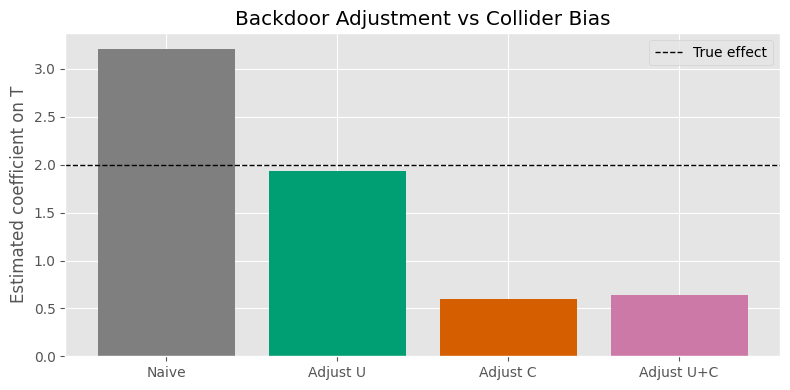

In [ ]:
labels = ['Naive', 'Adjust U', 'Adjust C', 'Adjust U+C']
vals = [est_naive, est_adjust_u, est_adjust_c, est_adjust_u_c]

plt.figure(figsize=(8, 4))
plt.bar(labels, vals, color=['#7f7f7f', '#009e73', '#d55e00', '#cc79a7'])
plt.axhline(tau_true, color='black', linestyle='--', linewidth=1, label='True effect')
plt.ylabel('Estimated coefficient on T')
plt.title('Backdoor Adjustment vs Collider Bias')
plt.legend()
plt.tight_layout()
plt.show()




### Exercise 1.5

1. In this DAG, which variable(s) should you control for to estimate the causal effect of `T` on `Y`?
# You should control for the confounder U in order to satisfy the backdoor criterion
2. Why does controlling for collider `C` move the estimate away from the true effect?
# Because controling a collider opens a backdoor path through which confounding occurs
3. Based on the numeric output, compare `Adjust U` vs `Adjust C` and explain the difference using backdoor logic.
# Adjusting for U leads to satisfying the bacdoor criterion and therefore an ATE very close to the true ATE, while adjusting for C introduces confounding and therefore an ATE very far from the true ATE

## Step 1.75: DoWhy Identification and Estimation

Lecture connection: bridges **Lectures 2-3** (assumptions + control set) with an implementation workflow from **Lecture 4**.

Now run a full `dowhy` pipeline on our observational dataset using confounders `X1`, `X2`, and `X3` as the adjustment set.

Workflow:

1. Build a causal model
2. Identify the estimand
3. Estimate effect with multiple estimators
4. Run a refuter check


In [ ]:
dowhy_df = pd.DataFrame({
    'X1': X[:, 0],
    'X2': X[:, 1],
    'X3': X[:, 2],
    'W': w.astype(int),
    'Y': y,
})

common_causes = ['X1', 'X2', 'X3']

dw_model = CausalModel(
    data=dowhy_df,
    treatment='W',
    outcome='Y',
    common_causes=common_causes,
)

dw_estimand = dw_model.identify_effect(proceed_when_unidentifiable=True)
print('Identified estimand:')
print(dw_estimand)


In [15]:
dw_est_lr = dw_model.estimate_effect(
    dw_estimand,
    method_name='backdoor.linear_regression',
)

dw_est_psw = dw_model.estimate_effect(
    dw_estimand,
    method_name='backdoor.propensity_score_weighting',
)

print(f"DoWhy linear-regression estimate: {dw_est_lr.value:.3f}")
print(f"DoWhy PS-weighting estimate:      {dw_est_psw.value:.3f}")
print(f"Ground-truth ATE (simulation):    {data['true_ate']:.3f}")

print("\nAbsolute errors vs truth:")
print(f"  linear_regression: {abs(dw_est_lr.value - data['true_ate']):.3f}")
print(f"  ps_weighting:      {abs(dw_est_psw.value - data['true_ate']):.3f}")

# Quick placebo refuter for one estimate
refute_lr = dw_model.refute_estimate(
    dw_estimand,
    dw_est_lr,
    method_name='placebo_treatment_refuter',
    placebo_type='permute',
    num_simulations=20,
    random_state=7,
)

print("\nPlacebo refuter (linear_regression):")
print(refute_lr)



DoWhy linear-regression estimate: 1.242
DoWhy PS-weighting estimate:      1.271
Ground-truth ATE (simulation):    1.306

Absolute errors vs truth:
  linear_regression: 0.064
  ps_weighting:      0.035


             Note: The underlying distribution may not be Normal. We assume that it approaches normal with the increase in sample size.



Placebo refuter (linear_regression):
Refute: Use a Placebo Treatment
Estimated effect:1.2416258917164136
New effect:-0.017702537648271056
p value:0.281423762889763



### Exercise 1.75

1. Compare DoWhy `linear_regression` and `propensity_score_weighting`: which is closer to the known true ATE?
# The Propensity score weighting ATE, because treatment assignment is explicitly modeled via the propensity score, so weighting better corrects for the confounding
2. What does the placebo refuter suggest about whether the estimated effect is spurious?
# The placebo refuter suggest that the estimated effect isn't spurious. The placebo refuter shows that when treatment is randomly permuted, the estimated effect is close to zero (≈ −0.018) and not statistically significant (p ≈ 0.28).
3. If you removed `X2` from `common_causes`, what bias pattern would you expect and why?
# X2 would then not be controled for anymore, therefore we would end up with a confounder. Because X2 is a true confounder (it affects both treatment assignment via the propensity score and the outcome), removing it leaves an unblocked backdoor path.

## Step 2: S-Learner (`econml`)

Lecture connection: **Lecture 4** (meta-learners, S-learner).

An S-learner fits one outcome model with treatment as a feature, then compares predictions under `T=1` vs `T=0`.


In [16]:
s_learner = SLearner(overall_model=LinearRegression())
s_learner.fit(Y=y, T=w, X=X)
ite_s = s_learner.effect(X)
ate_s = float(np.mean(ite_s))

print(f"S-learner ATE: {ate_s:.3f}")
print(f"Error vs truth: {ate_s - data['true_ate']:+.3f}")


S-learner ATE: 1.242
Error vs truth: -0.064


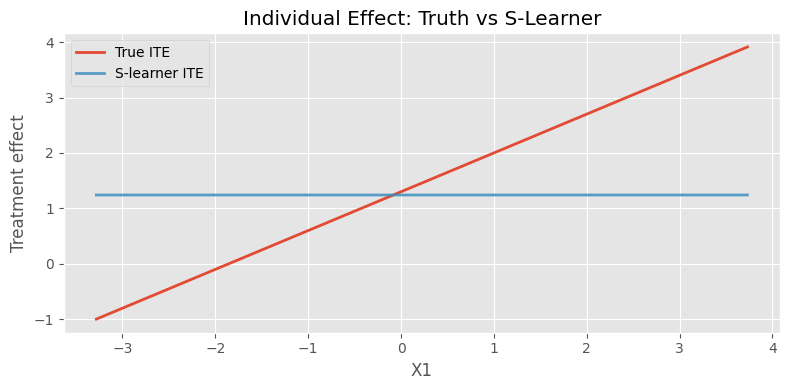

In [17]:
order = np.argsort(X[:, 0])

plt.figure(figsize=(8, 4))
plt.plot(X[order, 0], data['true_tau'][order], label='True ITE', linewidth=2)
plt.plot(X[order, 0], ite_s[order], label='S-learner ITE', linewidth=2, alpha=0.8)
plt.title('Individual Effect: Truth vs S-Learner')
plt.xlabel('X1')
plt.ylabel('Treatment effect')
plt.legend()
plt.tight_layout()
plt.show()




### Exercise 2

1. Why can one shared model underfit treatment-effect variation?
# Because if the treatment variable is one of the many covariates taken into account, the treatment effect can be neglected due to its relative low impact compared to the rest. Because a single shared model has to fit both the baseline outcome and the treatment effect at once, it often prioritizes the dominant pattern (the main outcome) and smooths over heterogeneity in treatment effects.


## Step 3: T-Learner (`econml`)

Lecture connection: **Lecture 4** (T-learner and comparison with S-learner).

A T-learner fits separate models for treated and control outcomes, then takes the difference.


In [21]:
t_learner = TLearner(models=LinearRegression())
t_learner.fit(Y=y, T=w, X=X)
ite_t = t_learner.effect(X)
ate_t = float(np.mean(ite_t))

print(f"T-learner ATE: {ate_t:.3f}")
print(f"Error vs truth: {ate_t - data['true_ate']:+.3f}")


T-learner ATE: 1.239
Error vs truth: -0.067


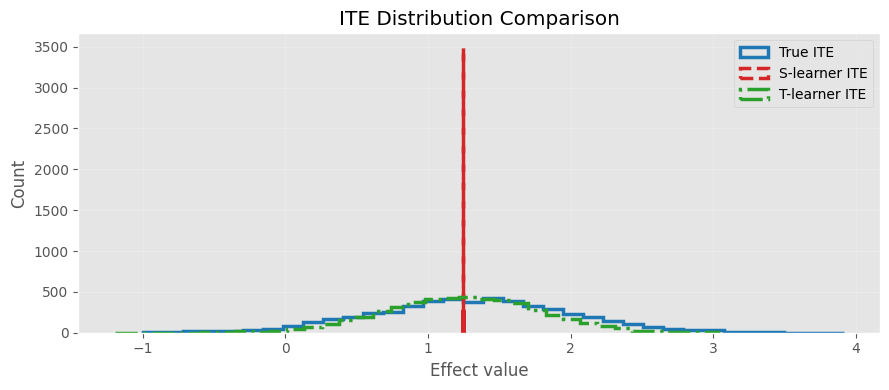

In [22]:
plt.figure(figsize=(9, 4))
bins = 35

# Use outlined histograms so overlapping distributions remain visible.
plt.hist(data['true_tau'], bins=bins, histtype='step', linewidth=2.5, color='#1f77b4', label='True ITE')
plt.hist(ite_s, bins=bins, histtype='step', linewidth=2.5, linestyle='--', color='#d62728', label='S-learner ITE')
plt.hist(ite_t, bins=bins, histtype='step', linewidth=2.5, linestyle='-.', color='#2ca02c', label='T-learner ITE')

plt.title('ITE Distribution Comparison')
plt.xlabel('Effect value')
plt.ylabel('Count')
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()


### Exercise 3

1. Which learner captures heterogeneity better in this run, S or T?
# The T-learner because it is more flexible and it doesn't underestimate the impact of the treatment effect. Because it fits separate models for treated and control groups, it can learn different patterns in each and thus pick up variation in treatment effects, whereas the S-learner uses one shared model and tends to smooth/underfit heterogeneity.
2. When can T-learner perform worse despite being more flexible?
# Because it splits the data into treated and control groups, each model gets fewer samples—so with small sample sizes, high noise, or extreme treatment imbalance, the estimates become high-variance and unstable, sometimes worse than the more constrained S-learner.
3. Reduce to `n=400`. Which learner degrades more, and why?
#The T-learner because it is more sensitive to sample size when making models, since it learns two models based on two parts of the data, each part then becomes smaller.

## Step 3.5: Benchmark Base-Learner Selection

Lecture connection: extends **Lecture 4** meta-learner discussion by explicitly testing base-model sensitivity.

Now benchmark how the **base learner choice** affects meta-learner performance.

We compare three base models inside `econml` S- and T-learners:

- `LinearRegression`
- `RandomForestRegressor`
- `GradientBoostingRegressor`

For each run we evaluate:

- `ATE absolute error`
- `ITE mean squared error`

Then we run **paired t-tests** versus the linear baseline in both scenarios (`baseline` and `nonlinear_stress`) so you can compare easier and harder data-generating settings directly.


In [31]:
def simulate_benchmark_data(seed, n=900, noise_std=2.0, stress=False):
    rng = np.random.default_rng(seed)

    x1 = rng.normal(0.0, 1.0, n)
    x2 = rng.normal(0.0, 1.0, n)
    x3 = rng.binomial(1, 0.45, n).astype(float)
    X_b = np.column_stack([x1, x2, x3])

    logits = -0.2 + 1.0 * x1 - 0.85 * x2 + 0.6 * x3
    prop = 1.0 / (1.0 + np.exp(-logits))
    w_b = rng.binomial(1, prop).astype(int)

    if stress:
        tau_b = 1.1 + 1.0 * np.sin(1.2 * x1) + 0.5 * (x2 ** 2 - 1.0) + 0.4 * x1 * x3 #in a stress setting both tau_b and mu0_b are more complex
        mu0_b = 1.8 + 1.2 * np.sin(x1) - 1.0 * np.cos(1.1 * x2) + 0.9 * x3 + 0.8 * x1 * x2 + 0.25 * (x1 ** 3)
    else:
        tau_b = 1.3 + 0.7 * x1
        mu0_b = 2.0 + 1.2 * x1 - 1.1 * x2 + 0.8 * x3 + 0.5 * x1 * x2

    y_b = mu0_b + tau_b * w_b + rng.normal(0.0, noise_std, n)
    ate_b = float(np.mean(tau_b))

    return X_b, w_b, y_b, tau_b, ate_b


In [25]:
alpha = 0.05
scenario_specs = [
    ('baseline', False, 1.0),
    ('nonlinear_stress', True, 0.9),
]

def compute_pvals(current_df, alpha=0.05):
    pval_rows = []
    for learner_name in ['S-learner', 'T-learner']:
        for metric in ['ate_abs_error', 'ite_mse']:
            pivot = (
                current_df[current_df['learner'] == learner_name]
                .pivot(index='run', columns='base_model', values=metric)
                .sort_index()
            )
            linear_vals = pivot['LinearRegression']
            for alt_model in ['RandomForest', 'GradientBoosting']:
                p_value = float(ttest_rel(linear_vals, pivot[alt_model]).pvalue)
                pval_rows.append({
                    'learner': learner_name,
                    'metric': metric,
                    'comparison': f'LinearRegression vs {alt_model}',
                    'p_value': p_value,
                    'significant_at_0.05': p_value < alpha,
                })
    return pd.DataFrame(pval_rows)

def run_single_scenario(stress_flag, noise_std, n_runs=12, n=900):
    if 'run_benchmark_once' in globals():
        return run_benchmark_once(stress=stress_flag, n_runs=n_runs, n=n, noise_std=noise_std)

    rows = []
    for run_id in range(n_runs):
        seed = 800 + run_id
        X_b, w_b, y_b, tau_b, ate_b = simulate_benchmark_data(
            seed=seed,
            n=n,
            noise_std=noise_std,
            stress=stress_flag,
        )

        for model_name in ['LinearRegression', 'RandomForest', 'GradientBoosting']:
            if model_name == 'LinearRegression':
                model_s = LinearRegression()
                model_t = LinearRegression()
            elif model_name == 'RandomForest':
                model_s = RandomForestRegressor(
                    n_estimators=140,
                    max_depth=6,
                    min_samples_leaf=8,
                    random_state=seed,
                    n_jobs=-1,
                )
                model_t = RandomForestRegressor(
                    n_estimators=140,
                    max_depth=6,
                    min_samples_leaf=8,
                    random_state=seed,
                    n_jobs=-1,
                )
            else:
                model_s = GradientBoostingRegressor(
                    random_state=seed,
                    n_estimators=180,
                    max_depth=3,
                    learning_rate=0.05,
                )
                model_t = GradientBoostingRegressor(
                    random_state=seed,
                    n_estimators=180,
                    max_depth=3,
                    learning_rate=0.05,
                )

            s_model = SLearner(overall_model=model_s)
            s_model.fit(Y=y_b, T=w_b, X=X_b)
            ite_s_b = s_model.effect(X_b)

            t_model = TLearner(models=model_t)
            t_model.fit(Y=y_b, T=w_b, X=X_b)
            ite_t_b = t_model.effect(X_b)

            rows.append({
                'run': run_id,
                'base_model': model_name,
                'learner': 'S-learner',
                'ate_abs_error': float(abs(np.mean(ite_s_b) - ate_b)),
                'ite_mse': float(np.mean((ite_s_b - tau_b) ** 2)),
            })
            rows.append({
                'run': run_id,
                'base_model': model_name,
                'learner': 'T-learner',
                'ate_abs_error': float(abs(np.mean(ite_t_b) - ate_b)),
                'ite_mse': float(np.mean((ite_t_b - tau_b) ** 2)),
            })

    return pd.DataFrame(rows)

benchmark_parts = []
summary_parts = []
pval_parts = []

for scenario_name, stress_flag, noise_std in scenario_specs:
    current_df = run_single_scenario(stress_flag=stress_flag, noise_std=noise_std, n_runs=12, n=900)
    current_pval_df = compute_pvals(current_df, alpha=alpha)
    current_summary_df = (
        current_df
        .groupby(['learner', 'base_model'])[['ate_abs_error', 'ite_mse']]
        .agg(['mean', 'std'])
        .round(4)
    )

    benchmark_parts.append(current_df.assign(scenario=scenario_name))
    summary_parts.append(
        current_summary_df.assign(scenario=scenario_name)
        .set_index('scenario', append=True)
        .reorder_levels(['scenario', 'learner', 'base_model'])
        .sort_index()
    )
    pval_parts.append(current_pval_df.assign(scenario=scenario_name))

    print(f'\n=== Scenario: {scenario_name} ===')
    print('Summary (mean/std across runs):')
    print(current_summary_df.to_string())
    print('\nPaired t-test p-values (vs LinearRegression):')
    print(current_pval_df.to_string(index=False))

benchmark_df = pd.concat(benchmark_parts, ignore_index=True)
summary_df = pd.concat(summary_parts).sort_index()
pval_df = pd.concat(pval_parts, ignore_index=True)

print('\nCombined significant comparisons by scenario:')
print(
    pval_df.groupby('scenario')['significant_at_0.05']
    .sum()
    .rename('n_significant')
    .to_string()
)



=== Scenario: baseline ===
Summary (mean/std across runs):
                           ate_abs_error         ite_mse        
                                    mean     std    mean     std
learner   base_model                                            
S-learner GradientBoosting        0.0907  0.0662  0.2302  0.0774
          LinearRegression        0.0806  0.0457  0.5007  0.0255
          RandomForest            0.2491  0.1419  0.4879  0.1696
T-learner GradientBoosting        0.0902  0.0817  0.4860  0.0884
          LinearRegression        0.0783  0.0441  0.3321  0.1286
          RandomForest            0.2670  0.0990  0.5752  0.1066

Paired t-test p-values (vs LinearRegression):
  learner        metric                           comparison      p_value  significant_at_0.05
S-learner ate_abs_error     LinearRegression vs RandomForest 4.199577e-03                 True
S-learner ate_abs_error LinearRegression vs GradientBoosting 6.381532e-01                False
S-learner       ite_mse

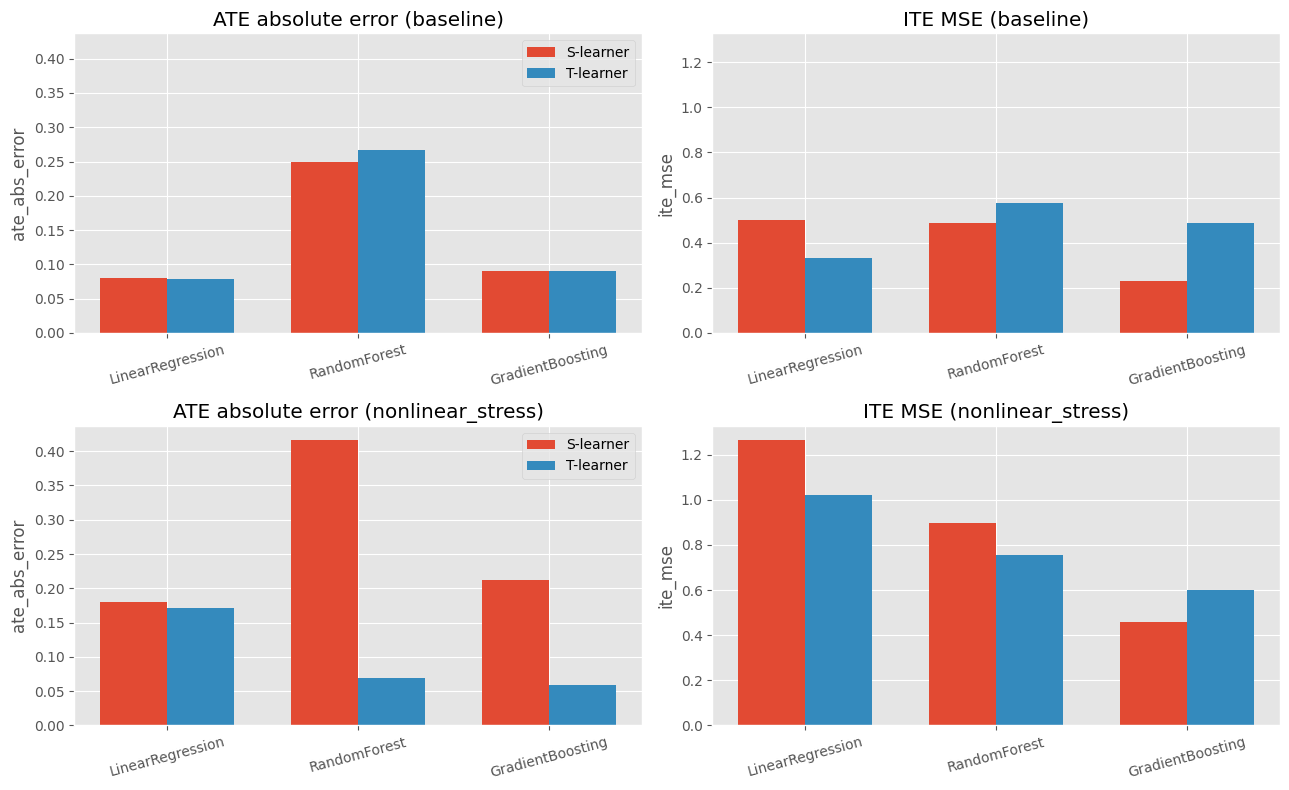

In [26]:
models = ['LinearRegression', 'RandomForest', 'GradientBoosting']
learners = ['S-learner', 'T-learner']
metrics = [('ate_abs_error', 'ATE absolute error'), ('ite_mse', 'ITE MSE')]
scenarios = ['baseline', 'nonlinear_stress']

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharey='col')

for row_idx, scenario_name in enumerate(scenarios):
    scenario_df = benchmark_df[benchmark_df['scenario'] == scenario_name]

    for col_idx, (metric, title) in enumerate(metrics):
        ax = axes[row_idx, col_idx]

        mean_vals = (
            scenario_df
            .groupby(['learner', 'base_model'])[metric]
            .mean()
            .unstack('base_model')
            .reindex(index=learners, columns=models)
        )

        x = np.arange(len(models))
        width = 0.35
        ax.bar(x - width / 2, mean_vals.loc['S-learner'].values, width, label='S-learner')
        ax.bar(x + width / 2, mean_vals.loc['T-learner'].values, width, label='T-learner')

        ax.set_xticks(x)
        ax.set_xticklabels(models, rotation=15)
        ax.set_ylabel(metric)
        ax.set_title(f'{title} ({scenario_name})')
        if col_idx == 0:
            ax.legend()

plt.tight_layout()
plt.show()


### Exercise 3.5

1. For each scenario (`baseline` and `nonlinear_stress`), which base learner gives the lowest **ITE MSE** for S-learner and for T-learner?
For the baseline scenario, S-learner: Gradient Boosting, T-learner: Linear Regression. In the baseline scenario, LinearRegression performs about as well as the more flexible models, and many differences (especially vs. GradientBoosting) are not statistically significant. This indicates that when the data-generating process is mostly linear, simple models are sufficient and not very sensitive to misspecification.

For the nonlinear_stress scenario, S-learner and T-learner: Gradient Boosting. In the nonlinear stress scenario, LinearRegression performs much worse, while RandomForest and GradientBoosting perform better, and all pairwise differences become statistically significant. This shows that the methods are highly sensitive to nonlinearity, and flexible models are needed to capture complex treatment-effect patterns.

2. For each scenario, which pairwise comparisons are significant at `alpha=0.05`?
For the baseline scenario, the statistically significant comparisons at α = 0.05 are: for the S-learner, LinearRegression vs RandomForest (ATE error) and LinearRegression vs GradientBoosting (ITE MSE); for the T-learner, LinearRegression vs RandomForest (ATE error) and LinearRegression vs both RandomForest and GradientBoosting (ITE MSE). For the nonlinear stress scenario, all pairwise comparisons are significant for both S-learner and T-learner, across both ATE error and ITE MSE.

3. How do the baseline and stress results differ, and what does that say about sensitivity to nonlinearity?
The baseline results, represent results in an easier datagenerating setting, while the stress results a more difficult datagenerating setting.


## Step 4: Propensity Scores and Overlap

Lecture connection: **Lecture 2** (positivity/overlap) + **Lecture 4** (propensity score methods).

Estimate propensity scores from observed data, inspect overlap, and evaluate covariate balance before/after IPW.


In [27]:
prop_model = LogisticRegression(max_iter=2000)
prop_model.fit(X, w)
p_hat = prop_model.predict_proba(X)[:, 1]

corr = np.corrcoef(p_hat, data['true_propensity'])[0, 1]
print(f"Estimated propensity range: [{p_hat.min():.3f}, {p_hat.max():.3f}]")
print(f"Correlation with true propensity: {corr:.3f}")




Estimated propensity range: [0.009, 0.991]
Correlation with true propensity: 1.000


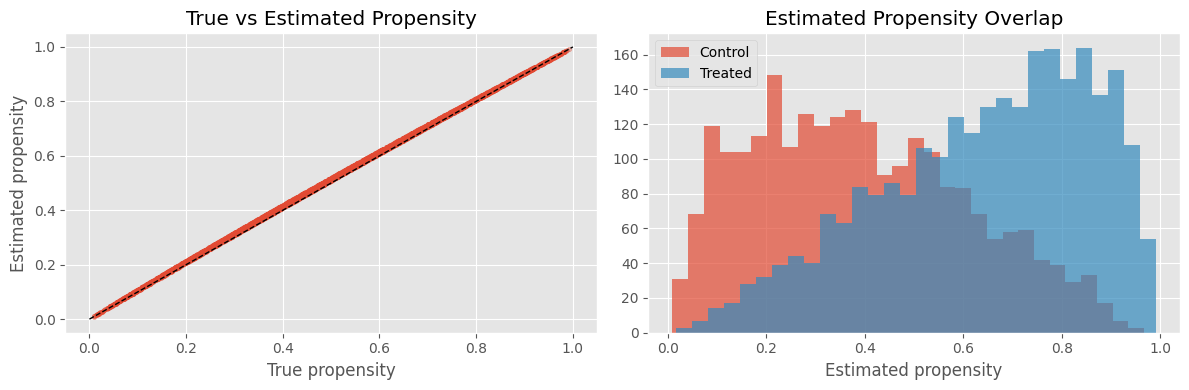


SMD before -> after IPW
  X1: +0.778 -> -0.011
  X2: -0.657 -> +0.018
  X3: +0.219 -> +0.052


In [28]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].scatter(data['true_propensity'], p_hat, s=10, alpha=0.35)
ax[0].plot([0, 1], [0, 1], 'k--', linewidth=1)
ax[0].set_title('True vs Estimated Propensity')
ax[0].set_xlabel('True propensity')
ax[0].set_ylabel('Estimated propensity')

ax[1].hist(p_hat[w == 0], bins=30, alpha=0.7, label='Control')
ax[1].hist(p_hat[w == 1], bins=30, alpha=0.7, label='Treated')
ax[1].set_title('Estimated Propensity Overlap')
ax[1].set_xlabel('Estimated propensity')
ax[1].legend()

plt.tight_layout()
plt.show()

weights_ipw = w / np.clip(p_hat, 1e-3, 1) + (1 - w) / np.clip(1 - p_hat, 1e-3, 1)

print('\nSMD before -> after IPW')
for j in range(X.shape[1]):
    xj = X[:, j]

    # Unweighted SMD
    mt = xj[w == 1].mean()
    mc = xj[w == 0].mean()
    vt = xj[w == 1].var()
    vc = xj[w == 0].var()
    smd_before = float((mt - mc) / np.sqrt((vt + vc) / 2 + 1e-12))

    # Weighted SMD
    wt_t = weights_ipw[w == 1]
    wt_c = weights_ipw[w == 0]

    mt_w = np.average(xj[w == 1], weights=wt_t)
    mc_w = np.average(xj[w == 0], weights=wt_c)
    vt_w = np.average((xj[w == 1] - mt_w) ** 2, weights=wt_t)
    vc_w = np.average((xj[w == 0] - mc_w) ** 2, weights=wt_c)
    smd_after = float((mt_w - mc_w) / np.sqrt((vt_w + vc_w) / 2 + 1e-12))

    print(f"  X{j+1}: {smd_before:+.3f} -> {smd_after:+.3f}")


### Exercise 4

1. Do diagnostics suggest the propensity model is reasonable here?
Yes. The estimated propensities align almost perfectly with the true propensities (points lie on the 45° line), indicating good model fit, and there is clear overlap between treated and control groups (no severe positivity violation). Additionally, the standardized mean differences drop close to zero after weighting, showing that covariate balance is successfully achieved.

2. Did IPW reduce imbalance? Use SMD changes to justify your answer.
By reweighting the data, IPW creates a pseudo-population in which the distribution of covariates is similar between treated and control groups—essentially mimicking randomization.The standardized mean differences (SMDs) drop substantially after weighting: for example,
X1 goes from about +0.778 to +0.011, X2 from −0.657 to +0.018, and X3 from +0.219 to +0.052. Since all post-weighting SMDs are close to zero (typically < 0.1), this indicates that the covariates are well balanced after IPW.

3. What failure mode appears when many propensities approach 0 or 1?
Positivity violation because it means that many individuals in the dataset are assigned treatment or not and that there's not a lot of overlap.

## Step 5: IPW and Matching Estimates

Lecture connection: **Lecture 4** (matching, propensity score matching, pseudo-population/IPW).

Use the estimated propensity scores to compute:

- IPW ATE
- 1:1 nearest-neighbor matching ATE (on propensity scores)


In [32]:
# IPW estimate
e = np.clip(p_hat, 1e-3, 1 - 1e-3)
ate_ipw = float(np.mean(w * y / e - (1 - w) * y / (1 - e)))

# Matching estimate (1:1 nearest neighbor on propensity)
treated_idx = np.where(w == 1)[0]
control_idx = np.where(w == 0)[0]

nn_c = NearestNeighbors(n_neighbors=1)
nn_c.fit(p_hat[control_idx].reshape(-1, 1))
_, idx_c = nn_c.kneighbors(p_hat[treated_idx].reshape(-1, 1))
matched_controls = control_idx[idx_c[:, 0]]
att = np.mean(y[treated_idx] - y[matched_controls])

nn_t = NearestNeighbors(n_neighbors=1)
nn_t.fit(p_hat[treated_idx].reshape(-1, 1))
_, idx_t = nn_t.kneighbors(p_hat[control_idx].reshape(-1, 1))
matched_treated = treated_idx[idx_t[:, 0]]
atc = np.mean(y[matched_treated] - y[control_idx])

p_treated = len(treated_idx) / len(y)
ate_match = float(p_treated * att + (1 - p_treated) * atc)

results = {
    'True ATE': data['true_ate'],
    'Naive diff': naive_diff,
    'S-learner (econml)': ate_s,
    'T-learner (econml)': ate_t,
    'IPW': ate_ipw,
    'Matching': ate_match,
}

for k, v in results.items():
    print(f"{k:>20}: {v:.3f}")


            True ATE: 1.306
          Naive diff: 3.185
  S-learner (econml): 1.242
  T-learner (econml): 1.239
                 IPW: 1.291
            Matching: 1.301


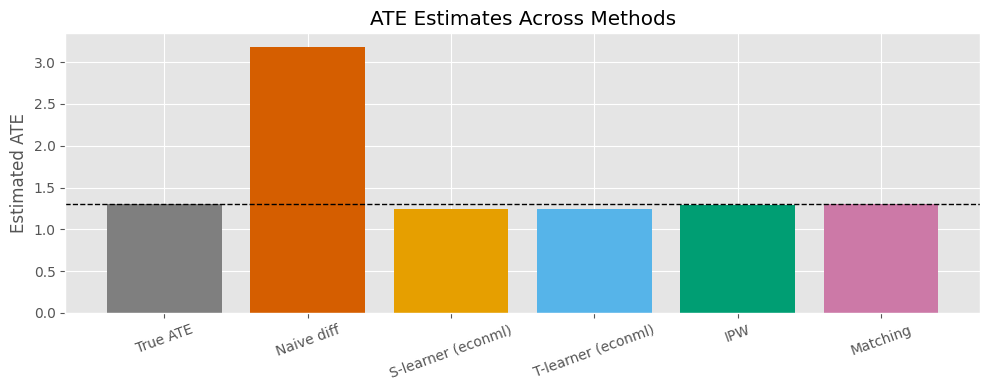

In [30]:
labels = list(results.keys())
values = [results[k] for k in labels]

plt.figure(figsize=(10, 4))
plt.bar(labels, values, color=['#7f7f7f', '#d55e00', '#e69f00', '#56b4e9', '#009e73', '#cc79a7'])
plt.axhline(data['true_ate'], color='black', linestyle='--', linewidth=1)
plt.title('ATE Estimates Across Methods')
plt.ylabel('Estimated ATE')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()




### Exercise 5

1. Which method is closest to the true ATE in your run?
Matching

2. Increase `noise_std` to `2.0` in simulation. Which methods become less stable?
methods that rely more on outcome modeling become less stable.
In particular, the S-learner and T-learner (especially with flexible models) become noisier because they are directly fitting
Y, so higher outcome noise increases variance in their estimates. The naive difference also becomes more variable for the same reason.
In contrast, IPW and matching are relatively less sensitive to outcome noise, since they rely more on the treatment assignment model (propensity scores) rather than directly modeling the noisy outcome.

3. How does overlap quality affect matching reliability?
When overlap is good, treated and control units have similar covariate distributions, so you can find close matches, leading to low bias and stable estimates.

## Optional Challenge: Stress-Test Overlap

Lecture connection: **Lecture 4** (positivity tension, estimator failure modes, identifiability caveats).

In `simulate_causal_data`, make treatment assignment more extreme (larger logit coefficients), then rerun.

Questions:

1. Which methods fail first?
2. How do overlap plots and SMD diagnostics reflect the failure?
3. Which mitigations would you apply (trimming, stabilized weights, model constraints)?
